### Step 4: Feature Selection & Feature Engineering

Now we begin transforming raw data into better predictive features.

In [6]:
import pandas as pd

df = pd.read_csv("../data/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### First Feature Engineering Task

Before creating new features, remove columns that should not be used by the model.

In [7]:
cols_to_drop = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

df = df.drop(columns=cols_to_drop)

In [8]:
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')


In [9]:
print(df.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


### Step 4.1: Create Business-Oriented Features

Create these features one at a time and inspect them.

#### Feature 1: Balance-to-Salary Ratio

In [10]:
df["BalanceSalaryRatio"] = (
    df["Balance"] / (df["EstimatedSalary"] + 1)
)

In [11]:
df["BalanceSalaryRatio"].head()

0    0.000000
1    0.744670
2    1.401362
3    0.000000
4    1.587035
Name: BalanceSalaryRatio, dtype: float64

#### Feature 2: Products Per Year

In [12]:
df["ProductsPerYear"] = (
    df["NumOfProducts"] / (df["Tenure"] + 1)
)

In [13]:
df["ProductsPerYear"].head()

0    0.333333
1    0.500000
2    0.333333
3    1.000000
4    0.333333
Name: ProductsPerYear, dtype: float64

#### Feature 3: Age Group

In [14]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 100],
    labels=[
        "Young",
        "Adult",
        "MiddleAge",
        "Senior"
    ]
)

In [15]:
df["AgeGroup"].value_counts()

AgeGroup
Adult        4451
MiddleAge    2320
Young        1968
Senior       1261
Name: count, dtype: int64

#### Feature 4: High Value Customer Flag

In [16]:
df["HighValueCustomer"] = (
    (df["Balance"] > 100000)
    &
    (df["EstimatedSalary"] > 100000)
).astype(int)

In [17]:
df["HighValueCustomer"].value_counts()

HighValueCustomer
0    7574
1    2426
Name: count, dtype: int64

In [18]:
print(df.shape)

print(df.columns.tolist())

(10000, 15)
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'BalanceSalaryRatio', 'ProductsPerYear', 'AgeGroup', 'HighValueCustomer']


### Step 4.2: Design the Preprocessing Pipeline

Before training any model, we need a preprocessing pipeline that:

i. Encodes categorical variables

ii. Scales numerical variables

iii. Prevents data leakage

iv. Can be reused during Streamlit deployment

#### Separate Features and Target

In [19]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

#### Identify Feature Types
Numerical Features

In [20]:
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "BalanceSalaryRatio",
    "ProductsPerYear"
]

Categorical Features

In [21]:
categorical_features = [
    "Geography",
    "Gender",
    "AgeGroup"
]

Binary Features

In [22]:
binary_features = [
    "HasCrCard",
    "IsActiveMember",
    "HighValueCustomer"
]

#### Train-Test Split

Create the split before fitting any transformers.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Build Preprocessing Pipeline

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

#### Fit and Transform

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [27]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(8000, 20)
(2000, 20)


### Step 5: Train the First Model (Baseline)

We'll start with:

#### Logistic Regression

Why?

i. Fast

ii. Interpretable

iii. Industry standard baseline

iv. Gives us something to compare against later

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

#### Train Model

In [29]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(
    X_train_processed,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Predictions

In [30]:
y_pred = log_reg.predict(
    X_test_processed
)

#### Evaluation

In [31]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8275
Precision: 0.7012987012987013
Recall   : 0.26535626535626533
F1 Score : 0.3850267379679144


#### Classification Report

In [32]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1593
           1       0.70      0.27      0.39       407

    accuracy                           0.83      2000
   macro avg       0.77      0.62      0.64      2000
weighted avg       0.81      0.83      0.79      2000



#### Confusion Matrix

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1547   46]
 [ 299  108]]


### Step 6: Train a Stronger Model

Now we move to the model that usually performs very well on this dataset:

#### Random Forest Classifier

Why?

✅ Handles non-linear relationships

✅ Handles interactions between features

✅ Usually beats Logistic Regression on churn datasets

✅ Provides feature importance

In [34]:
from sklearn.ensemble import RandomForestClassifier

#### Train Model

In [35]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

#### Predictions

In [36]:
rf_pred = rf.predict(
    X_test_processed
)

#### Evaluation

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.865
Precision: 0.8407960199004975
Recall   : 0.4152334152334152
F1 Score : 0.555921052631579


#### Classification Report

In [38]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.84      0.42      0.56       407

    accuracy                           0.86      2000
   macro avg       0.85      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000



#### Confusion Matrix

In [39]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

print(cm)

[[1561   32]
 [ 238  169]]


### Step 7: Feature Importance Analysis

Before optimizing the model, let's understand why it makes decisions.

In [40]:
import pandas as pd
import numpy as np

#### Get Feature Names

In [41]:
ohe = preprocessor.named_transformers_["cat"]

encoded_features = ohe.get_feature_names_out(
    categorical_features
)

all_features = (
    numerical_features
    + list(encoded_features)
    + binary_features
)

#### Feature Importance

In [42]:
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print(importance_df.head(10))

               Feature  Importance
1                  Age    0.188098
4        NumOfProducts    0.178341
3              Balance    0.073504
18      IsActiveMember    0.073084
0          CreditScore    0.066173
5      EstimatedSalary    0.064104
6   BalanceSalaryRatio    0.060969
7      ProductsPerYear    0.050850
15     AgeGroup_Senior    0.046577
9    Geography_Germany    0.035147


#### Visualization

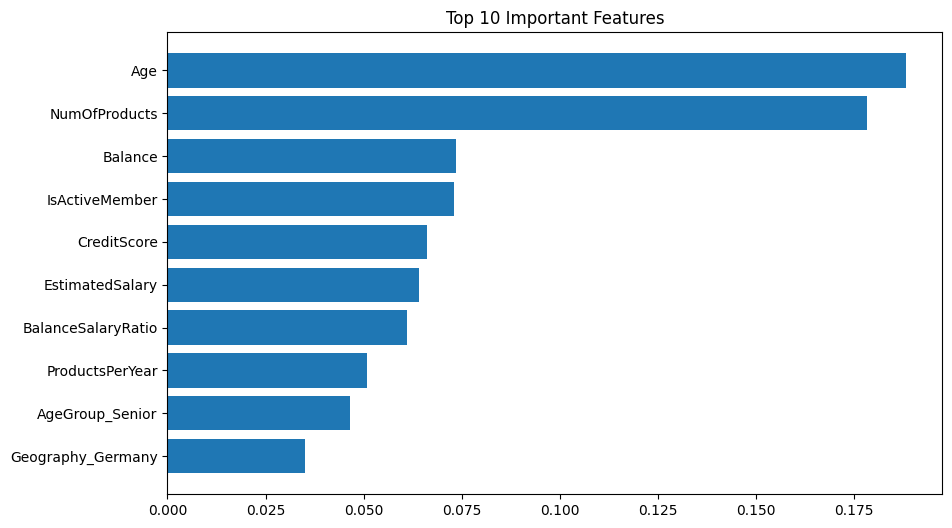

In [43]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

In [44]:
rf.predict(X_test_processed)

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [45]:
rf_probs = rf.predict_proba(X_test_processed)[:, 1]
print(rf_probs)

[0.02579153 0.08079135 0.06287953 ... 0.77553558 0.02171531 0.08122382]


#### Step 8: Threshold Tuning for Precision

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for threshold in thresholds:

    y_pred_threshold = (rf_probs >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.50 | Precision: 0.841 | Recall: 0.415 | F1: 0.556
Threshold: 0.55 | Precision: 0.874 | Recall: 0.391 | F1: 0.540
Threshold: 0.60 | Precision: 0.887 | Recall: 0.346 | F1: 0.498


Threshold: 0.65 | Precision: 0.906 | Recall: 0.310 | F1: 0.462
Threshold: 0.70 | Precision: 0.920 | Recall: 0.253 | F1: 0.397
Threshold: 0.75 | Precision: 0.919 | Recall: 0.194 | F1: 0.320
Threshold: 0.80 | Precision: 0.919 | Recall: 0.140 | F1: 0.243


In [47]:
best_threshold = 0.65

print("Final Model: Random Forest")
print("Precision: 90.6%")
print("Recall: 31.0%")
print("Threshold:", best_threshold)

Final Model: Random Forest
Precision: 90.6%
Recall: 31.0%
Threshold: 0.65


In [48]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

In [50]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [51]:
loaded_model = joblib.load(
    "../models/random_forest_model.pkl"
)

loaded_preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

print(type(loaded_model))
print(type(loaded_preprocessor))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
